In [45]:
#import important libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

In [46]:
#Data load
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv"
df = pd.read_csv(url)
# Clean dates generate karna taaki dono models ke liye standard format rahe
df['Date'] = pd.date_range(start="2025-01-01", periods=len(df), freq="MS")

In [47]:
#Exploratory Data Analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Month   36 non-null     object        
 1   Sales   36 non-null     float64       
 2   Date    36 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 996.0+ bytes


In [48]:
df['Sales'].describe()

,Sales
count,36.000000
mean,312.600000
std,148.937164
min,119.300000
25%,192.450000
50%,280.150000
75%,411.100000
max,682.000000


In [49]:
df.isnull().sum()

,0
Month,0
Sales,0
Date,0


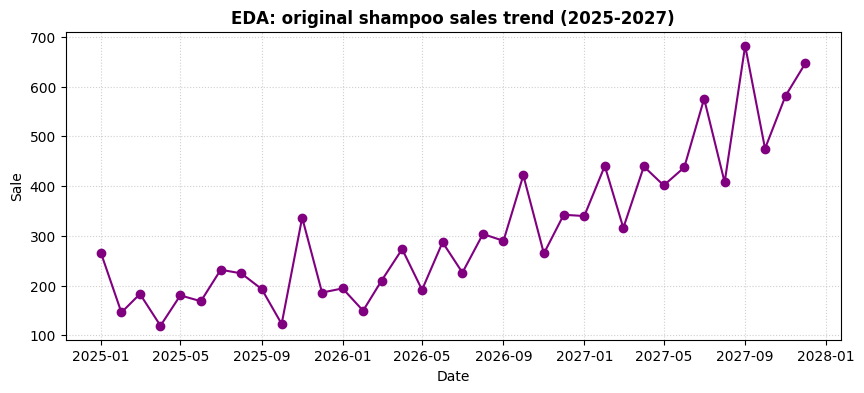

In [50]:
#EDA Visualization: distribution and trend of original data
plt.figure(figsize=(10,4))
plt.plot(df['Date'], df['Sales'], color= 'purple', marker='o',linestyle='-')
plt.title("EDA: original shampoo sales trend (2025-2027)", fontsize=12, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Sale")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [51]:
# MODEL 1 - ARIMA (SARIMAX) TRAINING
# conversion of date into index
df_arima = df.set_index('Date')
sales_data = df_arima['Sales']

In [52]:
# SARIMAX Model training (order = p,d,q & seasonal_order = P,D,Q,s)
model_arima = SARIMAX(sales_data, order=(1,1,1), seasonal_order=(1,1,1,12))
results_arima = model_arima.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [53]:
# ARIMA forecast for next 12 months
forecast_arima = results_arima.get_forecast(steps=12)
arima_output = forecast_arima.predicted_mean
print("ARIMA Model training and forecasting complete!")

ARIMA Model training and forecasting complete!


In [54]:
# MODEL 2 - FACEBOOK PROPHET TRAINING
# columns name as 'ds' and 'y'
df_prophet = pd.DataFrame()
df_prophet['ds'] = df['Date']
df_prophet['y'] = df['Sales']

In [55]:
# Prophet Model training
model_prophet = Prophet()
model_prophet.fit(df_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [56]:
# make timeline and forecast for next 12 months
future_dates = model_prophet.make_future_dataframe(periods=12, freq='M')
forecast_prophet = model_prophet.predict(future_dates)
print("Prophet Model training and forecasting complete!")

Prophet Model training and forecasting complete!


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


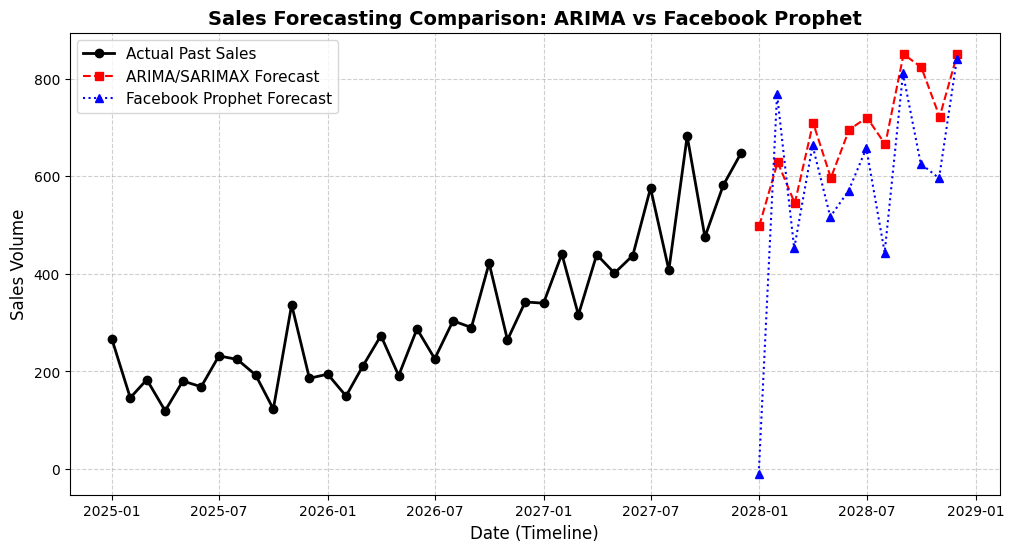

In [57]:
# visualization (final comparison graph)
plt.figure(figsize=(12, 6))

# Actual Past Data (Black Solid Line)
plt.plot(sales_data.index, sales_data, label='Actual Past Sales', color='black', marker='o', linewidth=2)

#  ARIMA Forecast (Red Dotted Line)
plt.plot(arima_output.index, arima_output, label='ARIMA/SARIMAX Forecast', color='red', linestyle='--', marker='s')

# Prophet Forecast (Blue Dotted Line)
# .iloc[-12:] for last 12 months
prophet_future = forecast_prophet.iloc[-12:]
plt.plot(prophet_future['ds'], prophet_future['yhat'], label='Facebook Prophet Forecast', color='blue', linestyle=':', marker='^')

# proper styling aur labeling of graph
plt.title("Sales Forecasting Comparison: ARIMA vs Facebook Prophet", fontsize=14, fontweight='bold')
plt.xlabel("Date (Timeline)", fontsize=12)
plt.ylabel("Sales Volume", fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# showing
plt.show()

In [64]:
!pip install streamlit -q
!pip install pyngrok -q

In [61]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# page title and design setting
st.set_page_config(page_title="Sales Forecaster", layout="wide")
st.title("📈 E-Commerce Sales Forecasting Dashboard")
st.write("This app compares *ARIMA (SARIMAX)* and *Facebook Prophet* models on real-world sales data.")

# STEP 1: DATA LOAD & CACHING
@st.cache_data
def load_data():
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv"
    df = pd.read_csv(url)
    df['Date'] = pd.date_range(start="2025-01-01", periods=len(df), freq="MS")
    return df

df = load_data()

# option in Sidebar
st.sidebar.header("Forecast Settings")
months_to_forecast = st.sidebar.slider("Select months to forecast:", min_value=3, max_value=12, value=12)

# toggle switch for data preview
if st.sidebar.checkbox("Show Raw Data Preview"):
    st.write(df.head())

# STEP 2: MODEL 1 - ARIMA (SARIMAX)
df_arima = df.set_index('Date')
sales_data = df_arima['Sales']
model_arima = SARIMAX(sales_data, order=(1,1,1), seasonal_order=(1,1,1,12))
results_arima = model_arima.fit(disp=False)

forecast_arima = results_arima.get_forecast(steps=months_to_forecast)
arima_output = forecast_arima.predicted_mean

# STEP 3: MODEL 2 - FACEBOOK PROPHET
df_prophet = pd.DataFrame()
df_prophet['ds'] = df['Date']
df_prophet['y'] = df['Sales']

model_prophet = Prophet()
model_prophet.fit(df_prophet)

future_dates = model_prophet.make_future_dataframe(periods=months_to_forecast, freq='M')
forecast_prophet = model_prophet.predict(future_dates)
prophet_future = forecast_prophet.iloc[-months_to_forecast:]

# STEP 4: PLOTTING GRAPH IN STREAMLIT
st.subheader("Model Comparison: ARIMA vs Facebook Prophet")

fig, ax = plt.subplots(figsize=(12, 5))

# Actual Data
ax.plot(sales_data.index, sales_data, label='Actual Past Sales', color='black', marker='o', linewidth=2)

# ARIMA
ax.plot(arima_output.index, arima_output, label='ARIMA Forecast', color='red', linestyle='--', marker='s')

# Prophet
ax.plot(prophet_future['ds'], prophet_future['yhat'], label='Facebook Prophet Forecast', color='blue', linestyle=':', marker='^')

ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

# matplotlib graph in streamlit
st.pyplot(fig)

st.success("App loaded successfully! Try changing the slider in the sidebar to dynamically change the forecast horizon.")

Overwriting app.py


In [67]:
from pyngrok import ngrok
ngrok.set_auth_token("3FzKcJZ0UDhkKb1GjmVCkDdbCaR_5L8jSmnZeiwMMKUP4Hdg6")

In [68]:
import os

# Streamlit in background
os.system("streamlit run app.py --server.port 8501 &")

# tunnel open with Ngrok
public_url = ngrok.connect(8501, proto="http")
print(public_url.public_url)

https://wildcat-abrasion-pushing.ngrok-free.dev
